In [2]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
import pymc as pm
import pytensor.tensor as pt

np.random.seed(42)
sns.set_theme(style="whitegrid")

In [3]:
# --- Cluster parameters ---
n_samples   = 1000
true_k      = 3
mix_weights = [0.4, 0.35, 0.25]

means = np.array([
    [0.0,  0.0],
    [5.0,  2.0],
    [2.0,  6.0],
])

covs = np.array([
    [[1.0, 0.3],  [0.3,  0.8]],
    [[1.2, -0.4], [-0.4, 1.0]],
    [[0.8, 0.2],  [0.2,  1.5]],
])

# --- Sample data ---
cluster_sizes = np.random.multinomial(n_samples, mix_weights)
X_list, z_list = [], []

for k, (n, mu, sigma) in enumerate(zip(cluster_sizes, means, covs)):
    X_list.append(np.random.multivariate_normal(mu, sigma, n))
    z_list.append(np.full(n, k))

X = np.vstack(X_list)          # shape (N, 2)
z = np.concatenate(z_list)     # true cluster labels

df = pd.DataFrame(X, columns=["x1", "x2"])
df["cluster"] = z.astype(str)

print(f"Total points: {len(X)}  |  Cluster counts: {dict(zip(*np.unique(z, return_counts=True)))}")

Total points: 1000  |  Cluster counts: {0: 387, 1: 356, 2: 257}


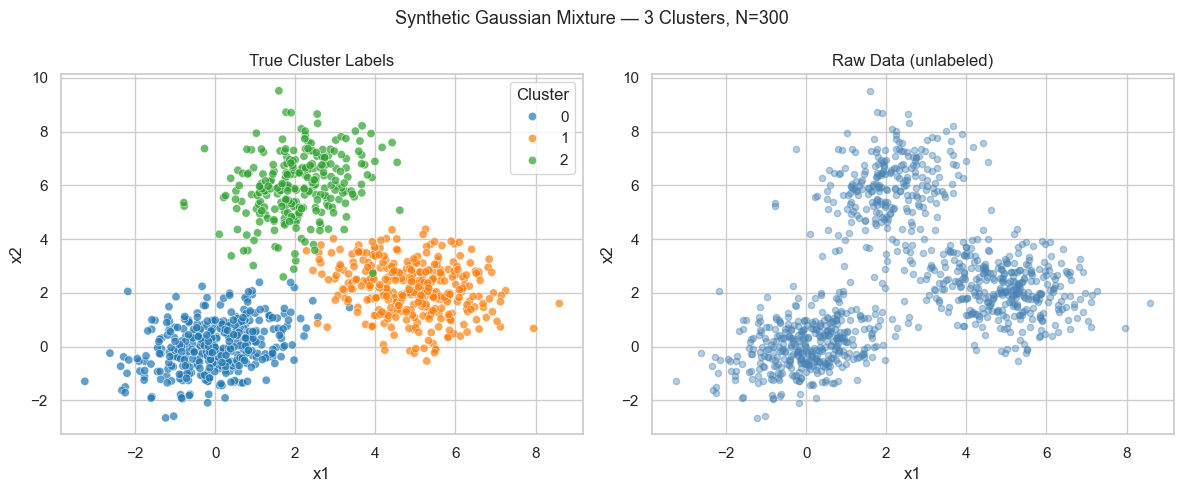

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: colored by true cluster ---
sns.scatterplot(data=df, x="x1", y="x2", hue="cluster",
                palette="tab10", alpha=0.7, ax=axes[0])
axes[0].set_title("True Cluster Labels")
axes[0].legend(title="Cluster")

# --- Right: no labels (as the DP will see it) ---
axes[1].scatter(X[:, 0], X[:, 1], color="steelblue", alpha=0.4, s=20)
axes[1].set_title("Raw Data (unlabeled)")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")

plt.suptitle("Synthetic Gaussian Mixture — 3 Clusters, N=300", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
K_max = 10   # truncation: max number of components DP can use
N, D  = X.shape

with pm.Model() as dp_model:

    # --- Concentration parameter (alpha) ---
    alpha = pm.Gamma("alpha", alpha=1.0, beta=1.0)

    # --- Stick-breaking weights ---
    v = pm.Beta("v", alpha=1.0, beta=alpha, shape=K_max - 1)
    v_cumprod   = pt.concatenate([[1.0], pt.cumprod(1.0 - v)])
    stick_weights = pt.concatenate([v, [1.0]]) * v_cumprod
    w = pm.Deterministic("w", stick_weights / stick_weights.sum())

    # --- Component means and standard deviations ---
    mu    = pm.Normal("mu",    mu=0.0,  sigma=5.0, shape=(K_max, D))
    sigma = pm.HalfNormal("sigma", sigma=2.0,      shape=(K_max, D))

    # --- Mixture likelihood (MvNormal with diagonal covariance) ---
    comp_dists = [pm.MvNormal.dist(mu=mu[k], cov=pt.diag(sigma[k] ** 2)) for k in range(K_max)]
    obs = pm.Mixture("obs", w=w, comp_dists=comp_dists, observed=X)

print(dp_model)

In [ ]:
with dp_model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        random_seed=42,
        progressbar=True,
    )

print(pm.summary(trace, var_names=["alpha", "w"]))